In [12]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from brain_transforms import get_spatial_transform_list 
from data import DicomDataset

In [33]:
data_dir = Path('/data/vision/polina/users/marcusbl/data')

dataset = DicomDataset(data_dir)
# dataset.set_norm(mask_method = 'stack')

Loading People Data: 100%|██████████| 30/30 [00:00<00:00, 215.90it/s]


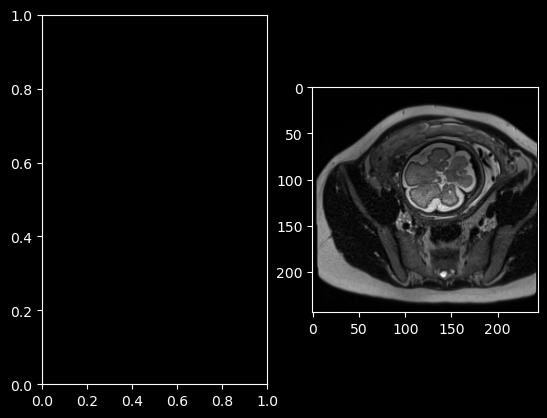

In [34]:
idx = 720

full = dataset[idx][0]

# mask = full[1]
scan = full[0]

fig, ax = plt.subplots(ncols = 2)
# ax[0].imshow(mask, vmin=0, vmax=1, cmap='grey')
ax[1].imshow(scan, cmap="gray")


bad


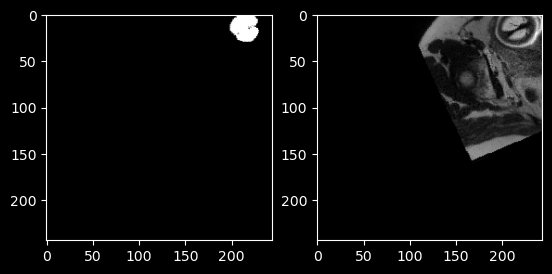

In [4]:
augs = get_spatial_transform_list(trans_perc = 0.40, translate_far = True)
# augs = get_spatial_transform_list(trans_perc = 0.20, translate_far = False)

for transform in augs:
    new_full = transform(full)
    if transform.mask_moves_outside(mask):
        print('bad')

new_mask = new_full[1]
new_scan = new_full[0]

fig, ax = plt.subplots(ncols = 2)
ax[0].imshow(new_mask, vmin=0, vmax=1, cmap='grey')
ax[1].imshow(new_scan, cmap="gray")

In [19]:
dataloader = DataLoader(dataset, batch_size = 32)

all_rows = []
all_cols = []

# around 1 minute
for data, label in tqdm(dataloader): 
    batch, rows, cols = torch.where(data[:, 1, :, :] > 0) # only look at mask
    all_rows.extend(rows.tolist())
    all_cols.extend(cols.tolist())

100%|██████████| 229/229 [00:55<00:00,  4.11it/s]


(array([  46470.,  258896.,  753191., 2305217., 5964946., 7031398.,
        4004818., 1011544.,  267273.,   38767.]),
 array([  3. ,  25.9,  48.8,  71.7,  94.6, 117.5, 140.4, 163.3, 186.2,
        209.1, 232. ]),
 <BarContainer object of 10 artists>)

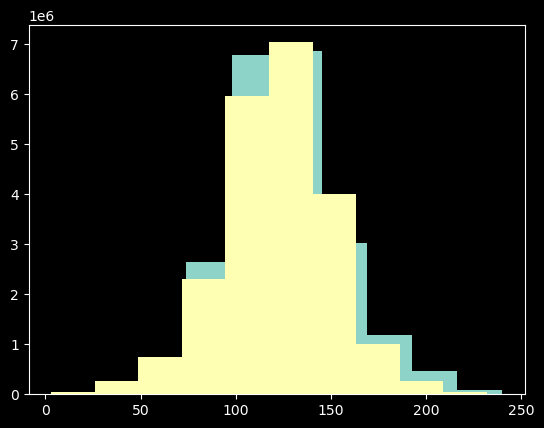

In [20]:
plt.hist(all_rows, label = 'rows')
plt.hist(all_cols, label = 'cols')

In [41]:
rows = torch.tensor(all_rows)
cols = torch.tensor(all_cols)

H = 244
W = 244

flat_idx = rows * W + cols
hist = torch.bincount(flat_idx, minlength=H * W).reshape(H, W)

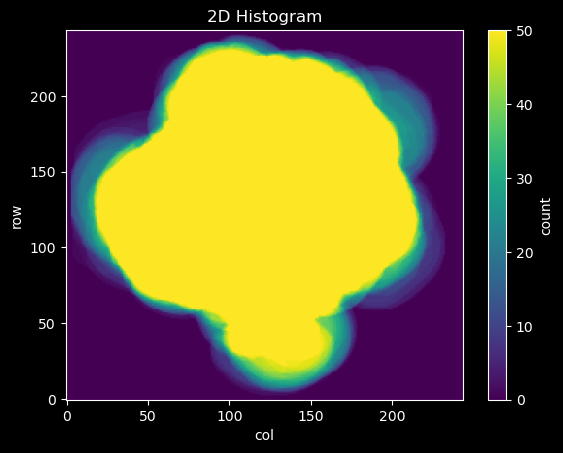

In [50]:
plt.imshow(hist.cpu(), aspect='auto', vmin = 0, vmax = 50)
plt.colorbar(label="count")
plt.xlabel("col")
plt.ylabel("row")
plt.gca().invert_yaxis()
plt.title("2D Histogram")
plt.show()

tensor(69)